In [2]:
# !pip install --no-cache-dir -r requirements.txt
# !pip install numpy==1.23.5
# !pip install scipy==1.13.1

In [3]:
import json
import numpy as np
from torch.utils import data
import h5py
import torch
from example.trainer import TrainerWassersteinNormalizedAutoEncoder
from example.loader import Loader
from example.architectures import Encoder, Decoder

In [53]:
scale = f["Normalisation"]["norm_scale"][:]
bias = f["Normalisation"]["norm_bias"][:]

KeyError: "Unable to synchronously open object (object 'Normalisation' doesn't exist)"

In [54]:
# import json
# import numpy as np
# import h5py
# import torch
# from torch.utils import data

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Parameters
batch_size = 1024
n_train_sample = 50000   # 50k for training
n_test_sample  = 20000   # 20k for validation

# Open HDF5 file
f = h5py.File("../training/v5/conditionsupdate_apr25.h5","r")

# Take sequential subset
train_data = f['data']["Background_data"]["Train"]["DATA"][:n_train_sample]
test_data  = f['data']["Background_data"]["Test"]["DATA"][:n_test_sample]
sig_data   = f['data']["Signal_data"]["GluGluHToBB_M-125"]["DATA"][:n_test_sample]

# Convert to torch tensors and flatten
x_train = torch.tensor(train_data.reshape(n_train_sample, -1), dtype=torch.float32, device=device)
x_test  = torch.tensor(test_data.reshape(n_test_sample, -1), dtype=torch.float32, device=device)
x_sig   = torch.tensor(sig_data.reshape(n_test_sample, -1), dtype=torch.float32, device=device)

# Calc mean and std for standardization
bias = x_train.mean(dim=0)
scale = x_train.std(dim=0)
scale[scale == 0] = 1.0  # prevent division by zero

x_train = (x_train - bias) / scale
x_test  = (x_test  - bias) / scale
x_sig   = (x_sig   - bias) / scale

# Create DataLoaders
train_loader = data.DataLoader(dataset=data.TensorDataset(x_train), batch_size=batch_size, shuffle=True)
val_loader   = data.DataLoader(dataset=data.TensorDataset(x_test),  batch_size=batch_size, shuffle=True)
val_loader_no_batch = data.DataLoader(dataset=data.TensorDataset(x_test),  batch_size=x_test.shape[0], shuffle=True)
sig_loader   = data.DataLoader(dataset=data.TensorDataset(x_sig),   batch_size=batch_size, shuffle=True)

print(f"x_train: {x_train.shape}, x_test: {x_test.shape}, x_sig: {x_sig.shape}")


x_train: torch.Size([50000, 57]), x_test: torch.Size([20000, 57]), x_sig: torch.Size([20000, 57])


In [57]:
f['data'].keys()

<KeysViewHDF5 ['Background_data', 'Normalisation', 'Signal_data']>

In [65]:
scale = f['data']["Normalisation"]["norm_scale"][:].reshape(-1)
bias = f['data']["Normalisation"]["norm_bias"][:].reshape(-1)

In [63]:
scale

array([[ 16.,   1.,  64.],
       [  8.,  32.,  64.],
       [  2.,  32.,  64.],
       [  2.,  32.,  64.],
       [  1.,  32.,  64.],
       [  8., 128., 256.],
       [  2., 128., 256.],
       [  2., 128., 256.],
       [  2., 128., 256.],
       [ 32.,  64.,  64.],
       [ 16.,  64.,  64.],
       [ 16.,  64.,  64.],
       [ 16.,  64.,  64.],
       [ 16.,  64.,  64.],
       [ 16.,  64.,  64.],
       [ 16.,  64.,  64.],
       [ 16.,  64.,  64.],
       [ 16.,  64.,  64.],
       [  8.,  64.,  64.]])

In [34]:
data_config = json.loads(f.attrs["config"])['data_config']
constituents = data_config["Read_configs"]["BACKGROUND"]["constituents"]
constituents

{'MET': [True],
 'EGAMMA': [True,
  True,
  True,
  True,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'MUON': [True, True, True, True, False, False, False, False],
 'JET': [True,
  True,
  True,
  True,
  True,
  True,
  True,
  True,
  True,
  True,
  False,
  False]}

In [67]:
x_train = torch.tensor(train_data.reshape(n_train_sample, -1), dtype=torch.float32, device=device)
x_test  = torch.tensor(test_data.reshape(n_test_sample, -1), dtype=torch.float32, device=device)
x_sig   = torch.tensor(sig_data.reshape(n_test_sample, -1), dtype=torch.float32, device=device)
x_train = (x_train.detach().cpu() - bias) / scale
x_test  = (x_test.detach().cpu()  - bias) / scale
x_sig   = (x_sig.detach().cpu()   - bias) / scale

In [68]:
print('mean of features')
print(x_train.mean(dim=0))

mean of features
tensor([-2.2699e+00,  0.0000e+00, -1.1247e+00, -1.7938e+00,  1.4396e-04,
        -1.1404e+00, -4.9982e+00,  3.5957e-05, -1.1414e+00, -4.6943e+00,
        -1.7791e-04, -1.1279e+00, -8.0502e+00, -1.2322e-04, -1.1308e+00,
        -1.6572e+00, -1.2736e-05, -1.1208e+00, -4.4623e+00,  1.5736e-02,
        -1.1175e+00, -4.4958e+00,  1.5744e-02, -1.1059e+00, -4.4997e+00,
         1.5745e-02, -1.1216e+00, -1.8250e+00,  1.7442e-04, -1.1277e+00,
        -2.8284e+00,  1.0956e-04, -1.1322e+00, -2.2782e+00,  1.2845e-04,
        -1.1365e+00, -1.8388e+00,  1.9380e-05, -1.1395e+00, -1.4525e+00,
         1.8838e-05, -1.1412e+00, -1.3914e+00,  1.7803e-05, -1.1420e+00,
        -1.3270e+00,  2.4609e-06, -1.1582e+00, -1.1950e+00, -3.7354e-06,
        -1.1584e+00, -1.1952e+00, -1.7920e-06, -1.1426e+00, -2.3905e+00,
         3.1738e-02, -1.1426e+00], dtype=torch.float64)


In [69]:
print('std of features')
print(x_train.std(dim=0))

std of features
tensor([7.0553e-02, 0.0000e+00, 1.0550e-02, 1.1066e-01, 2.7611e-02, 1.0381e-02,
        8.4989e-01, 2.6826e-02, 1.0969e-02, 7.4812e-01, 2.4751e-02, 1.1561e-02,
        2.9695e+00, 2.2530e-02, 1.1707e-02, 1.9184e-01, 4.5072e-03, 2.0098e-03,
        2.7220e-01, 1.6735e-03, 7.6445e-04, 8.8053e-02, 5.6754e-04, 2.7044e-04,
        2.5148e-02, 1.2851e-04, 8.3089e-05, 2.8613e-02, 1.0058e-02, 1.1197e-02,
        9.4112e-02, 7.8213e-03, 1.1611e-02, 7.0100e-02, 5.9419e-03, 1.0275e-02,
        4.8335e-02, 4.3585e-03, 7.9480e-03, 3.1086e-02, 2.9830e-03, 5.5976e-03,
        1.8803e-02, 2.0283e-03, 3.6404e-03, 1.0786e-02, 1.3164e-03, 2.2942e-03,
        5.6983e-03, 7.8092e-04, 1.3376e-03, 3.0282e-03, 4.1384e-04, 7.5831e-04,
        6.8631e-03, 2.6525e-04, 4.4523e-04], dtype=torch.float64)


In [13]:
from importlib import import_module

class MyLoader():
    def __init__(self, train_loader, val_loader, val_loader_no_batch, ood_loader) -> None:
        self.training_loader = train_loader
        self.validation_loader = val_loader
        self.validation_loader_no_batch = val_loader_no_batch
        self.ood_loader = ood_loader
        
loaders = MyLoader(train_loader, val_loader, val_loader_no_batch, sig_loader)

config = import_module("example.config")

In [14]:
input_size = x_train.shape[-1]
intermediate_architecture_encoder = (28,15)
intermediate_architecture_decoder = (24, 32, 64, 128, 57)
bottleneck_size = 8
output_path = "./output_mcmc_step_25_0.05"

encoder = Encoder(
    input_size=input_size,
    intermediate_architecture=intermediate_architecture_encoder,
    bottleneck_size=bottleneck_size,
    drop_out=None,
)
decoder = Decoder(
    output_size=input_size,
    intermediate_architecture=intermediate_architecture_decoder,
    bottleneck_size=bottleneck_size,
    drop_out=None,
)

trainer = TrainerWassersteinNormalizedAutoEncoder(
    config=config,
    loader=loaders,
    encoder=encoder,
    decoder=decoder,
    device=device,
    output_path=output_path,
    loss_function="wnae",  # can change to "ae" or "nae"
)


In [15]:
config.training_params

{'batch_size': 256,
 'es_patience': 5000,
 'n_epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.005,
 'lr_scheduler': 'ReduceLROnPlateau',
 'lr_scheduler_args': {'mode': 'min',
  'factor': 0.8,
  'patience': 20,
  'threshold': 0.001,
  'cooldown': 10,
  'threshold_mode': 'rel',
  'min_lr': 0},
 'wnae_parameters': {'sampling': 'pcd',
  'x_step': 25,
  'x_step_size': 0.05,
  'x_noise_std': 0.22,
  'x_temperature': 0.063,
  'x_bound': (-3, 3),
  'x_clip_grad': None,
  'x_reject_boundary': False,
  'x_mh': False,
  'z_step': 25,
  'z_step_size': 0.05,
  'z_temperature': 0.063,
  'z_noise_std': 1,
  'z_bound': None,
  'z_clip_grad': None,
  'z_reject_boundary': False,
  'z_mh': False,
  'spherical': False,
  'initial_dist': 'gaussian',
  'replay': True,
  'replay_ratio': 0.95,
  'buffer_size': 10000}}

In [19]:
config.training_params['x_step'] = 25
config.training_params['x_step_size'] = 0.05
config.training_params['z_step'] = 25
config.training_params['z_step_size'] = 0.05
config.training_params['n_epochs'] = 100

In [26]:
trainer.model

WNAE(
  (encoder): Encoder(
    (layers): ModuleList(
      (0): Linear(in_features=57, out_features=28, bias=True)
      (1): Linear(in_features=28, out_features=15, bias=True)
      (2): Linear(in_features=15, out_features=8, bias=True)
    )
    (dropout_layers): ModuleList()
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0): Linear(in_features=8, out_features=57, bias=True)
      (1): Linear(in_features=57, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): Linear(in_features=64, out_features=32, bias=True)
      (4): Linear(in_features=32, out_features=24, bias=True)
      (5): Linear(in_features=24, out_features=57, bias=True)
    )
    (dropout_layers): ModuleList()
  )
)

In [35]:
# trainer.train()

In [26]:
# trainer._TrainerWassersteinNormalizedAutoEncoder__save_model_checkpoint("current")

[INFO] Saved model checkpoint ./temp/current.pt


In [72]:
import pandas as pd
training_full = pd.read_csv('output_mcmc_step_25_0.05/training.csv')
training_full.head()

,epoch,training_loss,validation_loss,auc
0,0,77.609418,75.901023,0.993934
1,1,74.928109,78.543500,0.993300
2,2,65.955720,65.982711,0.992152
3,3,60.566209,64.681743,0.992873
4,4,59.952997,64.671291,0.992634


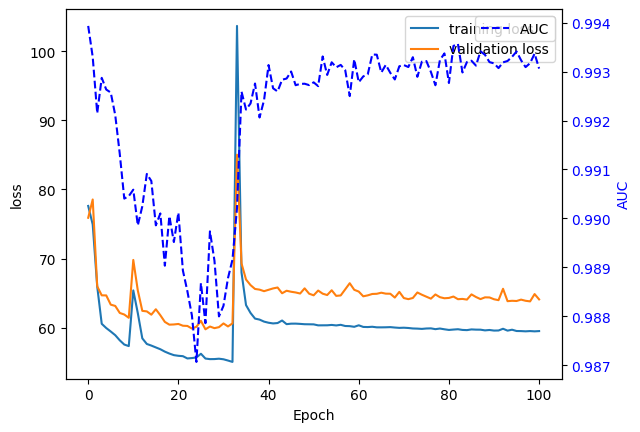

In [73]:
fig, ax1 = plt.subplots()

x_axis = list(range(training_full.shape[0]))
# Plot the first dataset on the left y-axis
ax1.plot(x_axis,training_full["training_loss"], label="training loss")
ax1.plot(x_axis,training_full["validation_loss"], label="validation loss")
ax1.legend()
ax1.set_xlabel('Epoch')
ax1.set_ylabel('loss', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create the second y-axis
ax2 = ax1.twinx()

# Plot the second dataset on the right y-axis
ax2.plot(x_axis, training_full["auc"], 'b--', label='AUC')
ax2.set_ylabel('AUC', color='b')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
# plt.plot(trainer.metrics_tracker["training_loss"], label="training loss")
# plt.plot(trainer.metrics_tracker["validation_loss"], label="validation loss")
# plt.legend()
# plt.show()
# plt.plot(trainer.metrics_tracker["auc"])

fig, ax1 = plt.subplots()

x_axis = list(range(len(trainer.metrics_tracker["training_loss"])))
# Plot the first dataset on the left y-axis
ax1.plot(x_axis,trainer.metrics_tracker["training_loss"], label="training loss")
ax1.plot(x_axis,trainer.metrics_tracker["validation_loss"], label="validation loss")
ax1.legend()
ax1.set_xlabel('Epoch')
ax1.set_ylabel('loss', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create the second y-axis
ax2 = ax1.twinx()

# Plot the second dataset on the right y-axis
ax2.plot(x_axis, trainer.metrics_tracker["auc"], 'b--', label='AUC')
ax2.set_ylabel('AUC', color='b')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.legend()
plt.show()

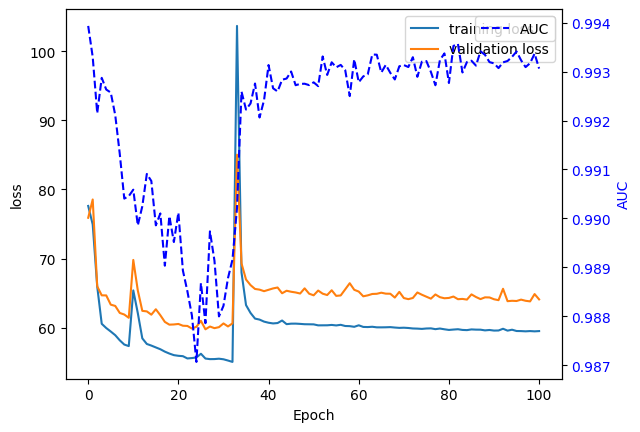

In [24]:
import matplotlib.pyplot as plt
# plt.plot(trainer.metrics_tracker["training_loss"], label="training loss")
# plt.plot(trainer.metrics_tracker["validation_loss"], label="validation loss")
# plt.legend()
# plt.show()
# plt.plot(trainer.metrics_tracker["auc"])

fig, ax1 = plt.subplots()

x_axis = list(range(len(trainer.metrics_tracker["training_loss"])))
# Plot the first dataset on the left y-axis
ax1.plot(x_axis,trainer.metrics_tracker["training_loss"], label="training loss")
ax1.plot(x_axis,trainer.metrics_tracker["validation_loss"], label="validation loss")
ax1.legend()
ax1.set_xlabel('Epoch')
ax1.set_ylabel('loss', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create the second y-axis
ax2 = ax1.twinx()

# Plot the second dataset on the right y-axis
ax2.plot(x_axis, trainer.metrics_tracker["auc"], 'b--', label='AUC')
ax2.set_ylabel('AUC', color='b')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.legend()
plt.show()

# Evaluation

In [74]:
from wnae import WNAE
from plot_util import calc_loss, calc_sig_loss, plot_sig_loss, plot_loss

def loss_mse(target, predicted):
    mse_loss = torch.mean((predicted - target).pow(2), dim=1)
    return mse_loss

model = WNAE(
            encoder=trainer.model.encoder,
            decoder=trainer.model.decoder,
            **config.training_params["wnae_parameters"],
        )
model = model.to(device)

signal_data   = f['data']["Signal_data"]#["GluGluHToBB_M-125"]["DATA"][:n_test_sample]

In [77]:
def calc_loss(model, data, loss_func):
    data = torch.reshape(data, (data.shape[0],-1))
    prediction_outputs = model(data, score_method="mse")
    loss = prediction_outputs.detach().cpu().numpy()
    # return loss_func(data, prediction_outputs)
    return loss

score_bkg = calc_loss(model, x_test, loss_mse)
plot_loss(score_bkg, 
               bins=np.arange(0, 100, 1), 
              )

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

plot threshold lines in background plot
match architecture

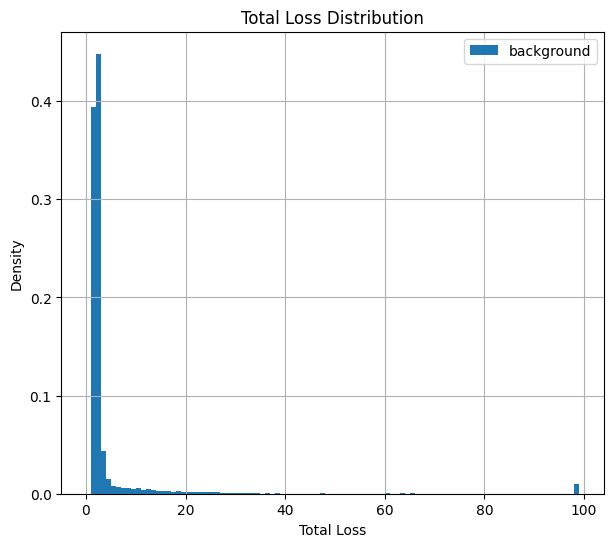

In [49]:
plot_loss(score_bkg, 
               bins=np.arange(0, 100, 1), 
              )

In [54]:
def calc_sig_loss(model, data, loss_func):
    sig_loss = {}
    for key in data.keys():
        sig = torch.tensor(data[key]['DATA'][:], device=device).to(torch.float32)
        sig = sig.reshape(sig.shape[0], -1)
        loss = model(sig, score_method="mae")
        sig_loss[key] = loss.detach().cpu().numpy()  # move to CPU before converting to numpy
    return sig_loss


loss_sig = calc_sig_loss(model, signal_data, loss_mse)

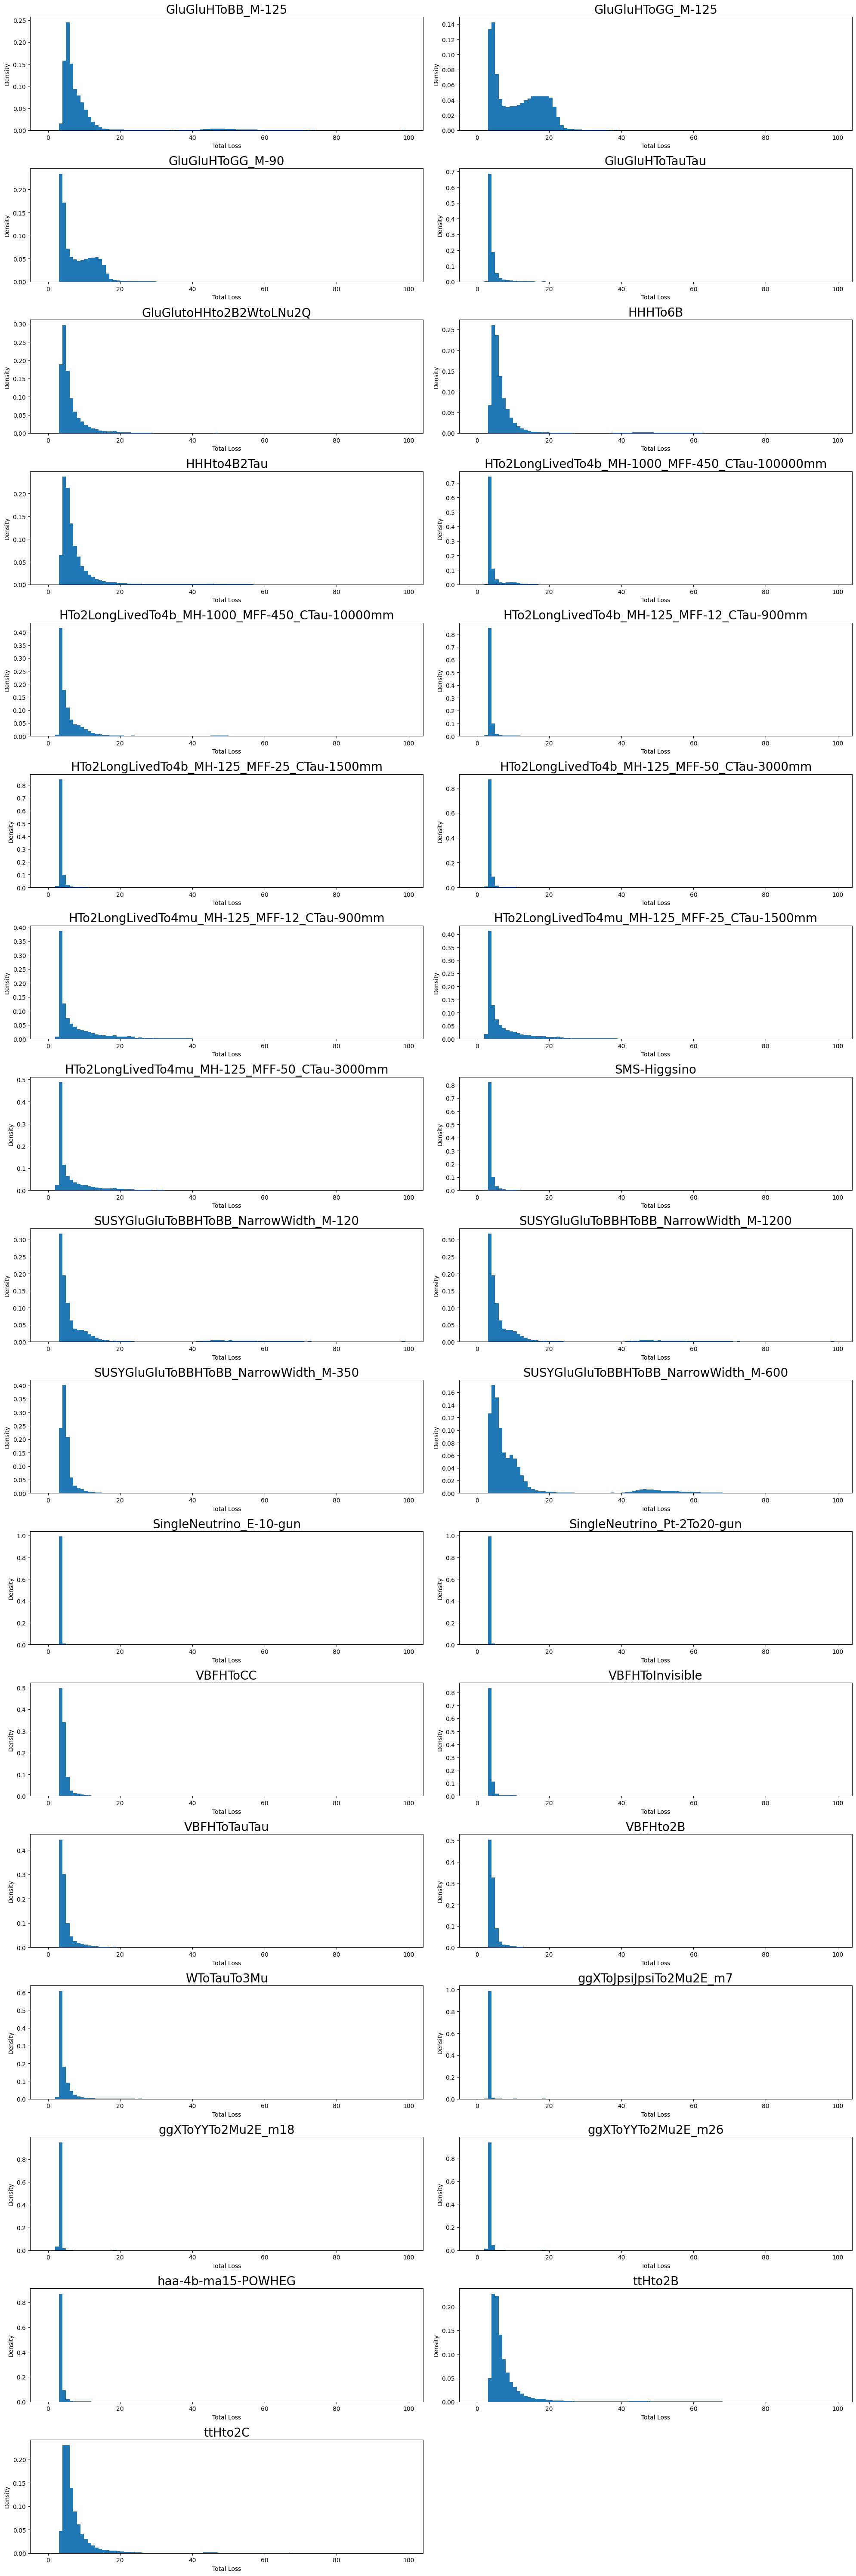

In [56]:
plot_sig_loss(loss_sig, 
                bins=np.arange(0, 100, 1),
            )

In [57]:
import yaml
import os
import metric
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import json
import torch

# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Input
# from tensorflow.keras.models import Sequential, Model
# import tensorflow as tf
# from qkeras import quantized_bits

class model_threshold_manager():
    def __init__(self,model, loss_func, config, score_method="mse"):#trimmed_model, loss_func, config):
        self.config = config
        self.model = model
        # self.trimmed_model = trimmed_model
        
        self.target_rate = self.config["target_rate"]
        self.threshold = None
        self.bc_rate_khz = self.config["bc_khz"]
        
        self.score_dict = {} #Internal variable not to be accessed directly
        self.data_file = None #Internal variable not to be accessed directly
        
        self.data_path = self.config["data_path"]
        self.HT_THRESHOLD = self.config["ht_threshold"]

        self.loss_func = loss_func
        self.score_method = score_method
        
        # Init ...
        self._open_hdf5()
        ap_fixed = self.config["precision"]
        # self.input_quantizer = quantized_bits(ap_fixed[0],ap_fixed[1],alpha=self.config["alpha"])
        print("Calculating Threshold...")
        self.get_threshold()
        print("Evaluating Score for model...")
        self.calculate_score()
        print("DONE")
        
    def _open_hdf5(self):
        self.data_file = h5py.File(self.data_path,"r")
    
    def get_threshold(self):
        x_test = self.data_file["Background_data"]["Test"]["DATA"][:]
        x_test = torch.tensor(np.reshape(x_test,(x_test.shape[0],-1))).to(torch.float32)       

        #claculate bkg score for full model
        # x_reco, z_mean, z_log_var= self.full_model.predict(self.input_quantizer(x_test),batch_size = 120000)
        # y_loss = self.loss_func(x_test, x_reco, z_mean, z_log_var)

        prediction_outputs = self.model(x_test, score_method = self.score_method)
        # if isinstance(prediction_outputs, list):
        #     prediction_outputs = tuple(prediction_outputs)
        # if not isinstance(prediction_outputs, tuple):
        #         prediction_outputs = (prediction_outputs,)
        # y_loss = self.loss_func(self.input_quantizer(x_test), *prediction_outputs)
        global y_loss
        y_loss = prediction_outputs.detach().numpy()
        
        
        
        # #Calculate bkg score for trimmed model
        # latent_axo_qk = self.trimmed_model.predict(self.input_quantizer(x_test),batch_size = 120000)
        # y_axo_qk = np.sum(latent_axo_qk**2, axis=1)
        print(sorted(y_loss)[-10:])
        
        threshold = {}
        # full_threshold = {}
        # axo_threshold = {}
        #Calculate threshold for each rate
        for target_rate in self.target_rate: 
            #converts from rate to percentile using predetermined hardware rate
            print("threshold percentile: ", 100-(target_rate/self.bc_rate_khz)*100)
            threshold[str(target_rate)] = np.percentile(y_loss, 100-(target_rate/self.bc_rate_khz)*100) 
            # threshold[str(target_rate)] = np.percentile(y_axo_qk, 100-(target_rate/self.bc_rate_khz)*100)
        # threshold['full'] = full_threshold
        # threshold['axo'] = axo_threshold
        self.threshold = threshold #Store threshold as dictionary of thresholds for the full and trimmed model

    def calculate_score(self):
        HT_THRESHOLD = self.HT_THRESHOLD
        signal_names = list(self.data_file["Signal_data"].keys())
        score = {}
        score["SIGNAL_NAMES"] = signal_names
        score["SCORE"] = {}
        for target_rate in self.target_rate:
            _raw_rate = [] #Rate/efficiency for model
            # _raw_axo_rate = [] #rate/efficiency for trimmed model
            _l1_rate = [] #rate/efficiency for l1 trigger
            _ht_rate = []
            _model_improv_rate = []
            for signal in signal_names:
                signal_data = self.data_file["Signal_data"][signal]["DATA"][:]
                signal_data = torch.tensor(np.reshape(signal_data,(signal_data.shape[0],-1))).to(torch.float32)
                signal_ET = self.data_file["Signal_data"][signal]["ET"][:]
                signal_HT = self.data_file["Signal_data"][signal]["HT"][:]
                signal_L1 = self.data_file["Signal_data"][signal]["L1bits"][:]
                signal_PU = self.data_file["Signal_data"][signal]["PU"][:]

                #Calc sig score for full model
                # signal_reco, z_mean, z_log_var = self.full_model.predict(self.input_quantizer(signal_data),batch_size = signal_data.shape[0],verbose=0)
                # signal_loss = self.loss_func(signal_data, signal_reco, z_mean, z_log_var)
                prediction_outputs = self.model(signal_data, score_method=self.score_method)
                # if isinstance(prediction_outputs, list):
                #     prediction_outputs = tuple(prediction_outputs)
                # if not isinstance(prediction_outputs, tuple):
                #         prediction_outputs = (prediction_outputs,)
                # signal_loss = self.loss_func(self.input_quantizer(signal_data), *prediction_outputs)
                
                signal_loss = prediction_outputs.detach().numpy()
                
                # #Calc signal score for trimmed model
                # latent_axo_qk = self.trimmed_model.predict(self.input_quantizer(signal_data),batch_size = signal_data.shape[0],verbose=0)
                # y_axo_qk = np.sum(latent_axo_qk**2, axis=1)

                nsamples = signal_data.shape[0]

                model_triggered = np.where(signal_loss > self.threshold[str(target_rate)])[0].tolist()
                # axo_triggered = np.where(y_axo_qk > self.threshold['axo'][str(target_rate)])[0].tolist()
                l1_triggered = np.where(signal_L1)[0].tolist()
                ht_triggered = np.where(signal_HT > HT_THRESHOLD)[0].tolist()

                raw_rate = len(model_triggered)/nsamples
                # raw_rate = len(axo_triggered)/nsamples
                l1_rate = len(l1_triggered)/nsamples
                ht_rate = len(ht_triggered)/nsamples

                model_improv = list(set(model_triggered)-set(l1_triggered))
                model_improv_rate = len(model_improv)/nsamples

                _raw_rate.append(raw_rate)
                _l1_rate.append(l1_rate)
                # _raw_axo_rate.append(raw_rate)
                _model_improv_rate.append(model_improv_rate)
                _ht_rate.append(ht_rate)

            score["SCORE"][str(target_rate)] = {
                "model_rate": _raw_rate,
                # "raw-axo":_raw_axo_rate,
                "L1_rate":_l1_rate,
                "HT_rate":_ht_rate,
                "model_improvement":_model_improv_rate,
            }

        self.score_dict = score ## Storing it here
        
    def get_raw_dict(self):
        return self.score_dict,self.threshold
    def get_score(self,thres, axo_scores=None, vae_model_scores=None):
        signal_names = self.data_file["Signal_data"].keys()
        df = pd.DataFrame()
        df["Signal Name"] = signal_names
        df['MODEL SCORE'] = self.score_dict["SCORE"][str(thres)]['model_rate']
        # df["AXO SCORE"] = axo_scores
        # df["VAE SCORE"] = vae_model_scores
        df["L1 SCORE"] = self.score_dict["SCORE"][str(thres)]['L1_rate']
        df["HT SCORE"] = self.score_dict["SCORE"][str(thres)]['HT_rate']
        df["MODEL Improvement"] = self.score_dict["SCORE"][str(thres)]['model_improvement']
        
        return df
    
config_thres = yaml.load(open("./utilities/config.yml","r"), Loader=yaml.Loader)
model_man_mse = model_threshold_manager(model=model,
                              loss_func=loss_mse,
                              config=config_thres['threshold'],
                              score_method="mse"
                              )

model_man_mae = model_threshold_manager(model=model,
                              loss_func=loss_mse,
                              config=config_thres['threshold'],
                              score_method="mae"
                              )

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './data/newdata/Data.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [23]:
print(sum(y_loss > 31))
print(len(y_loss))

10
2972127


In [24]:
import pandas as pd
file_path = "../MAE_performance.xlsx"

all_sheets = pd.read_excel(file_path, sheet_name=None)

axo_mae_scores = {}
vae_mae_model_scores = {}
for sheet_name, df in all_sheets.items():
    print(f"Sheet name: {sheet_name}")
    for idx, score in enumerate(df["MODEL SCORE"]):
        vae_mae_model_scores[idx] = vae_mae_model_scores.get(idx, list())
        vae_mae_model_scores[idx].append(score)
        
    for idx, score in enumerate(df["axo_score"]):
        axo_mae_scores[idx] = axo_mae_scores.get(idx, list())
        axo_mae_scores[idx].append(score)

Sheet name: 0.15kHz
Sheet name: 0.2kHz
Sheet name: 0.3kHz
Sheet name: 0.6kHz
Sheet name: 1kHz
Sheet name: 2kHz
Sheet name: 3kHz
Sheet name: 5kHz
Sheet name: 10kHz


In [25]:
import pandas as pd
file_path = "../mse_performance.xlsx"

all_sheets = pd.read_excel(file_path, sheet_name=None)

axo_mse_scores = {}
vae_mse_model_scores = {}
for sheet_name, df in all_sheets.items():
    print(f"Sheet name: {sheet_name}")
    for idx, score in enumerate(df["MODEL SCORE"]):
        vae_mse_model_scores[idx] = vae_mse_model_scores.get(idx, list())
        vae_mse_model_scores[idx].append(score)
        
    for idx, score in enumerate(df["axo_score"]):
        axo_mse_scores[idx] = axo_mse_scores.get(idx, list())
        axo_mse_scores[idx].append(score)

Sheet name: 0.15kHz
Sheet name: 0.2kHz
Sheet name: 0.3kHz
Sheet name: 0.6kHz
Sheet name: 1kHz
Sheet name: 2kHz
Sheet name: 3kHz
Sheet name: 5kHz
Sheet name: 10kHz


/var/folders/cr/lf3ftc1562j666v_rns8jtc00000gn/T/ipykernel_34278/2337836049.py:66: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)


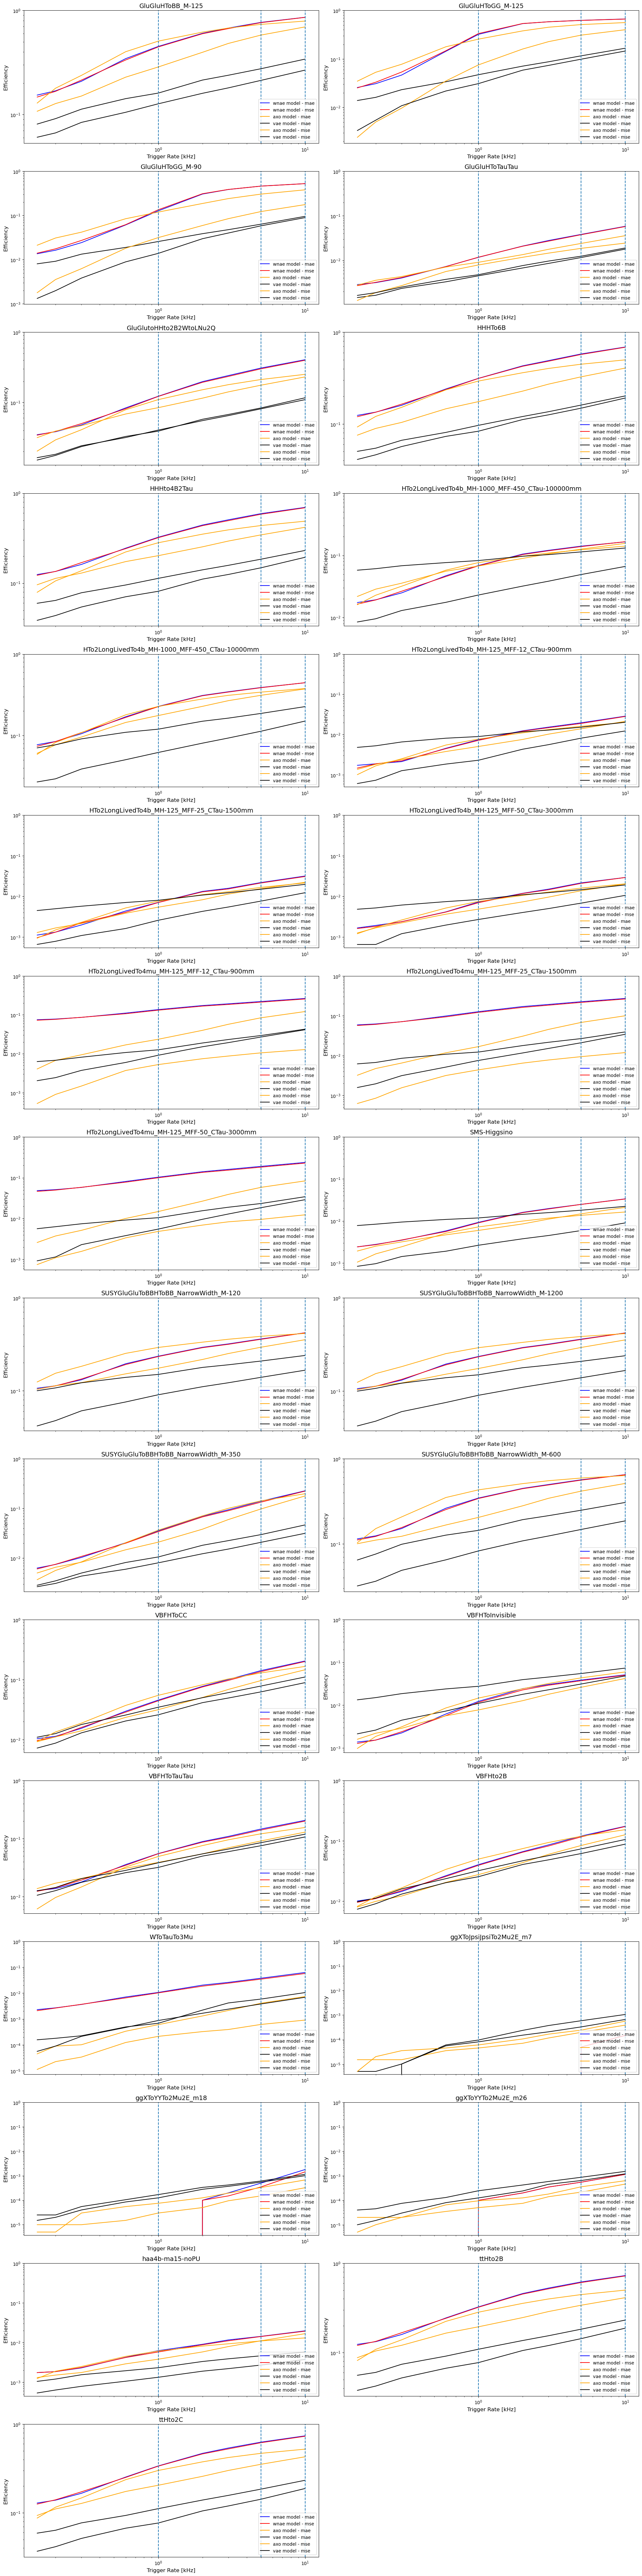

In [31]:
import matplotlib.pyplot as plt
score_dict_mse, thresholds= model_man_mse.get_raw_dict()
score_dict_mae, thresholds= model_man_mae.get_raw_dict()

signal_names = list(score_dict_mse['SIGNAL_NAMES'])
model_score_mse = score_dict_mse['SCORE']
model_score_mae = score_dict_mae['SCORE']
model_rates = list(model_score_mse.keys())
# trimmed_score = score_dict_trim['SCORE']
# trimmed_rates = list(trimmed_score.keys())
wnae_model_scores_mse = {}
wnae_model_scores_mae = {}

num_plots = len(signal_names)
fig, axes = plt.subplots(nrows=int(np.ceil(num_plots / 2)), 
                         ncols=2, 
                         figsize=(20, 80))
axes = axes.flatten()

for ax in axes[num_plots:]:
    ax.axis('off')
        
for i in range(len(signal_names)):
    ax = axes[i]
    full_score_mse = np.array([])
    full_score_mae = np.array([])

    # trim_score = np.array([])
    for rate in model_rates:
#         print(score[rate]['raw-axo'])#['full_model'][0])
        full_score_mse = np.append(full_score_mse, model_score_mse[rate]['model_rate'][i])
        full_score_mae = np.append(full_score_mae, model_score_mae[rate]['model_rate'][i])
        # trim_score = np.append(trim_score, trimmed_score[rate]['model_rate'][i])
        
    wnae_model_scores_mse[i] = full_score_mse
    wnae_model_scores_mae[i] = full_score_mae
    
    axo_mae_score = np.array(axo_mae_scores[i])
    vae_mae_model_score = np.array(vae_mae_model_scores[i])
    axo_mse_score = np.array(axo_mse_scores[i])
    vae_mse_model_score = np.array(vae_mse_model_scores[i])
    
    rates_int = [float(rate) for rate in model_rates]
    ax.plot(rates_int, full_score_mae, label='wnae model - mae', color='blue')
    ax.plot(rates_int, full_score_mse, label='wnae model - mse', color='red')
    
    ax.plot(rates_int, axo_mae_score, label='axo model - mae', color='orange')
    ax.plot(rates_int, vae_mae_model_score, label='vae model - mae', color='black')
    ax.plot(rates_int, axo_mse_score, label='axo model - mse', color='orange')
    ax.plot(rates_int, vae_mse_model_score, label='vae model - mse', color='black')
    
    # ax.plot(rates_int, trim_score, label='trimmed model', color='orange')

    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.xlim(rates_int[0], rates_int[-1])

    ax.set_xlabel("Trigger Rate [kHz]", fontsize=12)
    ax.set_ylabel('Efficiency', fontsize=12)
    
    ax.set_title(signal_names[i], fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.axvline(x=1, linestyle='--')
    ax.axvline(x=5, linestyle='--')
    ax.axvline(x=10, linestyle='--')
    ax.set_ylim(0,1)

plt.tight_layout()
# plt.savefig('./figures/signal_eff_plots_orig_results.png')
plt.show()

In [34]:
rate = 10
df = model_man_mae.get_score(rate)
# df['axo_score'] = trimmed_man.get_score(rate)['MODEL SCORE']
df

,Signal Name,MODEL SCORE,L1 SCORE,HT SCORE,MODEL Improvement
0,GluGluHToBB_M-125,0.859651,0.992977,0.994846,0.001359
1,GluGluHToGG_M-125,0.666701,0.884231,0.677413,0.003914
2,GluGluHToGG_M-90,0.527426,0.807127,0.509989,0.004219
3,GluGluHToTauTau,0.058380,0.400623,0.214480,0.000603
4,GluGlutoHHto2B2WtoLNu2Q,0.406658,0.871617,0.867346,0.002264
5,HHHTo6B,0.691020,0.954173,0.981735,0.001914
6,HHHto4B2Tau,0.695723,0.964662,0.972199,0.001857
7,HTo2LongLivedTo4b_MH-1000_MFF-450_CTau-100000mm,0.165273,0.421763,0.382850,0.000492
8,HTo2LongLivedTo4b_MH-1000_MFF-450_CTau-10000mm,0.445258,0.778469,0.708692,0.000366
9,HTo2LongLivedTo4b_MH-125_MFF-12_CTau-900mm,0.028770,0.302365,0.200122,0.000304
